In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Coffee.csv")
df

,Unnamed: 0,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
0,0,2015,Argentina,13051.0,14887.0,2.6,2.7,26614.0
1,1,2015,Argentina,13131.0,15055.0,2.6,3.0,27019.0
2,2,2015,Argentina,13305.0,15075.0,2.7,NaN,27232.0
3,3,2015,Brazil,21070.0,36806.0,1.9,1.9,54721.0
4,4,2015,Canada,18063.0,21734.0,3.9,4.0,38987.0
...,...,...,...,...,...,...,...,...
515,515,2023,USA,28629.0,0.0,5.3,0.0,0.0
516,516,2023,USA,28875.0,0.0,5.2,0.0,0.0
517,517,2023,Vietnam,NaN,34342.0,2.9,3.2,52222.0
518,518,2023,Vietnam,18557.0,34695.0,3.2,2.9,52867.0


In [5]:
df.shape

(520, 8)

In [8]:
df.columns

Index(['Unnamed: 0', 'Year', 'Country', 'Domestic Consumption', 'Exports',
       'Import Price', 'Export Price', 'Total Production'],
      dtype='object')

In [9]:
df.dtypes

Unnamed: 0                int64
Year                      int64
Country                  object
Domestic Consumption    float64
Exports                 float64
Import Price            float64
Export Price            float64
Total Production        float64
dtype: object

In [10]:
df.head()

,Unnamed: 0,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
0,0,2015,Argentina,13051.0,14887.0,2.6,2.7,26614.0
1,1,2015,Argentina,13131.0,15055.0,2.6,3.0,27019.0
2,2,2015,Argentina,13305.0,15075.0,2.7,NaN,27232.0
3,3,2015,Brazil,21070.0,36806.0,1.9,1.9,54721.0
4,4,2015,Canada,18063.0,21734.0,3.9,4.0,38987.0


In [11]:
df.tail()

,Unnamed: 0,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
515,515,2023,USA,28629.0,0.0,5.3,0.0,0.0
516,516,2023,USA,28875.0,0.0,5.2,0.0,0.0
517,517,2023,Vietnam,NaN,34342.0,2.9,3.2,52222.0
518,518,2023,Vietnam,18557.0,34695.0,3.2,2.9,52867.0
519,519,2023,Vietnam,18615.0,34840.0,3.0,NaN,52639.0


In [12]:
missing_counts = df.isna().sum()
missing_counts[missing_counts > 0]

Domestic Consumption    26
Exports                 26
Import Price            26
Export Price            26
Total Production        26
dtype: int64

In [13]:
df["Country"].nunique()

20

In [14]:
df["Year"].value_counts()

Year
2015    73
2021    61
2017    59
2020    58
2016    58
2019    57
2022    56
2023    54
2018    44
Name: count, dtype: int64

In [15]:
df["Country"].value_counts()

Country
France          31
Argentina       30
Colombia        30
Chile           29
South Africa    29
Germany         28
Mexico          28
Italy           28
Indonesia       27
China           26
India           26
USA             25
Vietnam         24
Canada          24
Turkey          24
Brazil          23
Ethiopia        23
Kenya           23
Thailand        22
Peru            20
Name: count, dtype: int64

In [17]:
df["Total Production"].min()

np.float64(0.0)

In [18]:
df["Total Production"].max()

np.float64(264565.0)

In [19]:
df["Total Production"].mean()

np.float64(46466.72672064777)

In [20]:
row = df.loc[df["Total Production"].idxmax()]
row[["Year","Country","Total Production"]]

Year                    2023
Country                China
Total Production    264565.0
Name: 480, dtype: object

In [21]:
missing_or_zero = df["Total Production"].isna() | (df["Total Production"] == 0)
missing_or_zero.sum(), df.loc[missing_or_zero, ["Year","Country","Total Production"]].head()

(np.int64(76),
     Year  Country  Total Production
 14  2015    China               NaN
 27  2015  Germany               0.0
 28  2015  Germany               0.0
 29  2015  Germany               0.0
 30  2015  Germany               0.0)

In [23]:
df["Import Price"].mean()

np.float64(3.1564777327935225)

In [27]:
df.groupby("Year")["Total Production"].sum()

Year
2015    2551154.0
2016    2163533.0
2017    2438153.0
2018    1793354.0
2019    2593378.0
2020    2756933.0
2021    2867085.0
2022    2681517.0
2023    3109456.0
Name: Total Production, dtype: float64

In [28]:
df.groupby("Country")["Total Production"].sum().sort_values(ascending=False).head(5)

Country
China        5682192.0
India        1902283.0
Mexico       1838210.0
France       1837554.0
Indonesia    1582361.0
Name: Total Production, dtype: float64

In [29]:
df.groupby("Country")["Export Price"].mean().sort_values(ascending=False).head(1)

Country
Canada    4.338095
Name: Export Price, dtype: float64

In [30]:
cond = df["Domestic Consumption"].notna() & df["Total Production"].notna() & (df["Domestic Consumption"] > df["Total Production"])
df.loc[cond, "Country"].value_counts()

Country
Germany    24
USA        22
Name: count, dtype: int64

In [31]:
subset = df[["Export Price","Total Production"]].dropna()
subset.corr().iloc[0,1]

np.float64(0.3442034661421092)

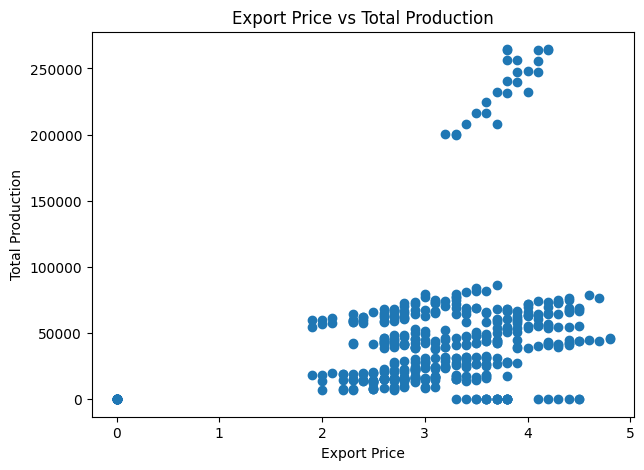

In [38]:
import matplotlib.pyplot as plt

plot_df = df[["Export Price","Total Production"]].dropna()
plt.figure(figsize=(7,5))
plt.scatter(plot_df["Export Price"], plot_df["Total Production"])
plt.xlabel("Export Price")
plt.ylabel("Total Production")
plt.title("Export Price vs Total Production")
plt.show()

#### **Key Insights from EDA**

1. The dataset contains 520 records covering 20 countries from 2015 to 2023.

2. Some columns have missing values, and the Total Production column also has several zero entries, which may affect comparisons.

3. China is the leading coffee producer, showing the highest production in a single year (2023) and the strongest growth over time.

4. The average import price across all records is around 3.16, while Canada has the highest average export price.

5. There is a slight positive relationship between export price and total production, meaning higher production is somewhat associated with higher export prices.